Intelligent Network Incident Resolution System

In [1]:
!pip install -q langgraph langchain langchain-google-genai google-search-results

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 890.7 kB/s eta 0:00:00


In [24]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, END,START
from langchain_google_genai import ChatGoogleGenerativeAI
from serpapi import GoogleSearch

In [ ]:
os.environ['GOOGLE_API_KEY']=''
os.environ['SERP_API_KEY']=''

In [6]:
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [31]:
class TelecomState(TypedDict):

    complaint: str

    # Understanding
    issue_type: str
    severity: str
    impact_scope: str

    # Investigation
    tower_status: str
    billing_status: str
    sim_status: str
    crm_history: str

    # Routing
    assigned_team: str
    routing_decision: str

    # Resolution
    customer_response: str
    technician_notes: str
    eta: str

In [8]:
def intent_extraction_node(state: TelecomState):

    complaint = state["complaint"]

    prompt = f"""
    Identify the telecom issue type from this complaint.

    Complaint:
    {complaint}

    Possible issue types:
    - slow_internet
    - outage
    - sim_issue
    - billing_issue
    - tower_congestion

    Return only the issue type.
    """

    response = llm.invoke(prompt)

    return {
        "issue_type": response.content.strip()
    }

In [9]:
def severity_detection_node(state: TelecomState):

    complaint = state["complaint"]

    prompt = f"""
    Analyze severity of this telecom complaint.

    Complaint:
    {complaint}

    Severity levels:
    - low
    - medium
    - high
    - critical

    Return only severity.
    """

    response = llm.invoke(prompt)

    return {
        "severity": response.content.strip()
    }

In [10]:
def scope_detection_node(state: TelecomState):

    complaint = state["complaint"]

    prompt = f"""
    Determine the impact scope of this complaint.

    Complaint:
    {complaint}

    Possible scopes:
    - individual
    - multiple_users
    - entire_region

    Return only the scope.
    """

    response = llm.invoke(prompt)

    return {
        "impact_scope": response.content.strip()
    }

In [27]:
def understanding_merge_node(state: TelecomState):

    return {
        "issue_type": state["issue_type"],
        "severity": state["severity"],
        "impact_scope": state["impact_scope"]
    }

In [11]:
def tower_check_node(state: TelecomState):

    issue = state["issue_type"]

    if issue == "outage":
        result = "Tower outage detected"

    else:
        result = "Tower functioning normally"

    return {
        "tower_status": result
    }

In [12]:
def billing_check_node(state: TelecomState):

    issue = state["issue_type"]

    if issue == "billing_issue":
        result = "Billing discrepancy found"

    else:
        result = "No billing issue"

    return {
        "billing_status": result
    }

In [13]:
def sim_check_node(state: TelecomState):

    issue = state["issue_type"]

    if issue == "sim_issue":
        result = "SIM activation issue detected"

    else:
        result = "SIM functioning normally"

    return {
        "sim_status": result
    }

In [14]:
def crm_history_node(state: TelecomState):

    complaint = state["complaint"]

    if "again" in complaint.lower():
        result = "Repeated complaint found"

    else:
        result = "No previous complaint"

    return {
        "crm_history": result
    }

In [28]:
def investigation_merge_node(state: TelecomState):

    return {
        "tower_status": state["tower_status"],
        "billing_status": state["billing_status"],
        "sim_status": state["sim_status"],
        "crm_history": state["crm_history"]
    }

In [29]:
def router(state: TelecomState):

    issue = state["issue_type"]
    severity = state["severity"]

    if severity == "critical":
        return "escalation_agent"

    elif issue == "billing_issue":
        return "billing_agent"

    elif issue == "outage":
        return "network_ops_agent"

    elif issue == "sim_issue":
        return "sim_support_agent"

    else:
        return "priority_agent"

In [32]:
def billing_agent_node(state: TelecomState):

    print("Billing Agent Handling Issue")

    return {
        "assigned_team": "Billing Support Team"
    }

In [33]:
def network_ops_agent_node(state: TelecomState):

    print("Network Ops Agent Handling Issue")

    return {
        "assigned_team": "Network Operations Team"
    }

In [34]:
def sim_support_agent_node(state: TelecomState):

    print("SIM Support Agent Handling Issue")

    return {
        "assigned_team": "SIM Support Team"
    }

In [35]:
def escalation_agent_node(state: TelecomState):

    print("Escalation Agent Handling Critical Issue")

    return {
        "assigned_team": "Critical Escalation Team"
    }

In [36]:
def priority_agent_node(state: TelecomState):

    print("Priority Handling Agent Activated")

    return {
        "assigned_team": "Priority Resolution Team"
    }

In [16]:
def customer_response_node(state: TelecomState):

    response = f"""
    Dear Customer,

    Your issue has been assigned to:
    {state['assigned_team']}.

    Severity:
    {state['severity']}

    Thank you for your patience.
    """

    return {
        "customer_response": response
    }

In [17]:
def technician_notes_node(state: TelecomState):

    notes = f"""
    Issue Type: {state['issue_type']}

    Tower Status: {state['tower_status']}

    Billing Status: {state['billing_status']}

    SIM Status: {state['sim_status']}
    """

    return {
        "technician_notes": notes
    }

In [18]:
def eta_prediction_node(state: TelecomState):

    severity = state["severity"]

    if severity == "critical":
        eta = "2 hours"

    elif severity == "high":
        eta = "4 hours"

    else:
        eta = "24 hours"

    return {
        "eta": eta
    }

In [37]:
graph = StateGraph(TelecomState)

# Nodes
graph.add_node("intent_extraction", intent_extraction_node)
graph.add_node("severity_detection", severity_detection_node)
graph.add_node("scope_detection", scope_detection_node)

graph.add_node("understanding_merge", understanding_merge_node)

graph.add_node("tower_check", tower_check_node)
graph.add_node("billing_check", billing_check_node)
graph.add_node("sim_check", sim_check_node)
graph.add_node("crm_history", crm_history_node)

graph.add_node("investigation_merge", investigation_merge_node)

graph.add_node("billing_agent", billing_agent_node)

graph.add_node("network_ops_agent", network_ops_agent_node)

graph.add_node("sim_support_agent", sim_support_agent_node)

graph.add_node("escalation_agent", escalation_agent_node)

graph.add_node("priority_agent", priority_agent_node)

graph.add_node("customer_response", customer_response_node)

graph.add_node("technician_notes", technician_notes_node)

graph.add_node("eta_prediction", eta_prediction_node)

graph.add_edge(START, "intent_extraction")

graph.add_edge(START, "severity_detection")

graph.add_edge(START, "scope_detection")

graph.add_edge("intent_extraction", "understanding_merge")

graph.add_edge("severity_detection", "understanding_merge")

graph.add_edge("scope_detection", "understanding_merge")

graph.add_edge("understanding_merge", "tower_check")

graph.add_edge("understanding_merge", "billing_check")

graph.add_edge("understanding_merge", "sim_check")

graph.add_edge("understanding_merge", "crm_history")

graph.add_edge("tower_check", "investigation_merge")

graph.add_edge("billing_check", "investigation_merge")

graph.add_edge("sim_check", "investigation_merge")

graph.add_edge("crm_history", "investigation_merge")

graph.add_conditional_edges(
    "investigation_merge",
    router,
    {
        "billing_agent": "billing_agent",

        "network_ops_agent": "network_ops_agent",

        "sim_support_agent": "sim_support_agent",

        "escalation_agent": "escalation_agent",

        "priority_agent": "priority_agent"
    }
)

graph.add_edge("billing_agent", "customer_response")
graph.add_edge("billing_agent", "technician_notes")
graph.add_edge("billing_agent", "eta_prediction")

graph.add_edge("network_ops_agent", "customer_response")
graph.add_edge("network_ops_agent", "technician_notes")
graph.add_edge("network_ops_agent", "eta_prediction")

graph.add_edge("sim_support_agent", "customer_response")
graph.add_edge("sim_support_agent", "technician_notes")
graph.add_edge("sim_support_agent", "eta_prediction")

graph.add_edge("escalation_agent", "customer_response")
graph.add_edge("escalation_agent", "technician_notes")
graph.add_edge("escalation_agent", "eta_prediction")

graph.add_edge("priority_agent", "customer_response")
graph.add_edge("priority_agent", "technician_notes")
graph.add_edge("priority_agent", "eta_prediction")

graph.add_edge("customer_response", END)

graph.add_edge("technician_notes", END)

graph.add_edge("eta_prediction", END)

workflow = graph.compile()

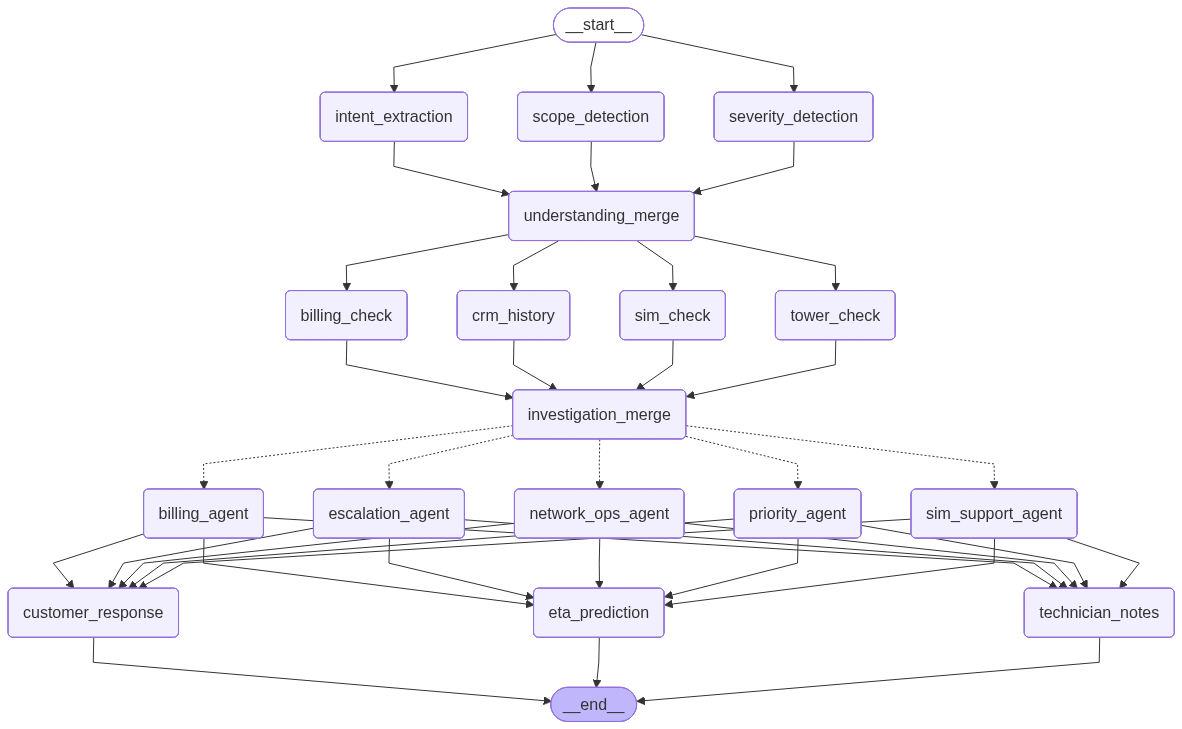

In [38]:
workflow

In [40]:
result = workflow.invoke(
    {
        "complaint": "Entire area has no signal since morning"
    }
)
print(result)

Network Ops Agent Handling Issue
{'complaint': 'Entire area has no signal since morning', 'issue_type': 'outage', 'severity': 'High', 'impact_scope': 'entire_region', 'tower_status': 'Tower outage detected', 'billing_status': 'No billing issue', 'sim_status': 'SIM functioning normally', 'crm_history': 'No previous complaint', 'assigned_team': 'Network Operations Team', 'customer_response': '\n    Dear Customer,\n\n    Your issue has been assigned to:\n    Network Operations Team.\n\n    Severity:\n    High\n\n    Thank you for your patience.\n    ', 'technician_notes': '\n    Issue Type: outage\n\n    Tower Status: Tower outage detected\n\n    Billing Status: No billing issue\n\n    SIM Status: SIM functioning normally\n    ', 'eta': '24 hours'}
